# Mpesa trasactions analysis

**Problem Statement**


## Importing libraries

In [37]:
import pandas as  pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Loading data

In [38]:
transactions_df = pd.read_csv(r'C:\Users\Administrator\M-PESA-Transaction-Anomaly-Scorer\data\transactions.csv')
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0


In [39]:
transactions_df.tail(10)

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
9990,TXN0006611,2024-11-01 16:00:00,146.670000,16,0,deposit,4,1,USER01658,3204.096831,0.045776,5508000.0,0,0,0
9991,TXN0007073,2024-03-28 08:00:00,489.578461,8,0,paybill,3,28,USER01104,4593.787755,0.106574,342000.0,0,0,0
9992,TXN0003467,2024-06-05 15:00:00,5833.460000,15,0,paybill,2,5,USER00870,802.209000,7.271746,9252000.0,0,0,0
9993,TXN0005540,2024-02-08 09:00:00,868.780000,9,0,withdraw,3,8,USER00099,1674.321179,0.518885,NaN,0,0,0
9994,TXN0005265,2024-08-07 13:00:00,2829.190000,13,0,send_money,2,7,USER01251,569.973885,4.963719,5961600.0,0,0,0
9995,TXN0006795,2024-01-10 11:00:00,5915.910000,11,0,withdraw,2,10,USER01136,3712.492545,1.593514,691200.0,0,0,0
9996,TXN0008931,2024-09-09 10:00:00,274.860000,10,0,buy_goods,0,9,USER01026,3030.333554,0.090703,6037200.0,0,0,0
9997,TXN0009424,2024-05-11 18:00:00,1685.630000,18,0,send_money,5,11,USER01067,4418.990756,0.381451,1155600.0,0,0,1
9998,TXN0006186,2024-02-22 16:00:00,2156.870000,16,0,send_money,3,22,USER00179,828.003301,2.604905,NaN,0,0,0
9999,TXN0001455,2024-11-01 18:00:00,4337.630000,18,0,paybill,4,1,USER01445,2735.067805,1.585931,2775600.0,0,0,0


In [40]:
transactions_df.sample(15)

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
6471,TXN0003522,2024-05-20 11:00:00,1033.310000,11,0,buy_goods,0,20,USER01673,4778.711803,0.216232,2516400.0,0,0,0
5227,TXN0007267,2024-07-30 12:00:00,3928.267581,12,0,withdraw,1,30,USER00640,4285.370196,0.916669,11120400.0,0,0,0
5352,TXN0000792,2024-02-05 13:00:00,482.250000,13,0,buy_goods,0,5,USER01869,4686.470663,0.102903,NaN,0,0,0
1554,TXN0000590,2024-01-13 09:00:00,189.360000,9,0,send_money,5,13,USER00719,3027.474321,0.062547,NaN,0,0,1
9982,TXN0001628,2024-08-02 09:00:00,806.840000,9,0,deposit,4,2,USER00243,4453.979555,0.181150,248400.0,0,0,0
6921,TXN0001209,2024-06-11 20:00:00,1994.630000,20,0,buy_goods,1,11,USER00426,1148.452143,1.736799,1414800.0,0,0,0
3349,TXN0008150,2024-02-23 13:00:00,957.180000,13,0,send_money,4,23,USER01646,3926.132916,0.243797,NaN,0,0,0
8173,TXN0008138,2024-01-23 13:00:00,307.510000,13,0,send_money,1,23,USER01892,4088.763836,0.075209,NaN,0,0,0
9872,TXN0009525,2024-12-05 13:00:00,780.950000,13,0,paybill,3,5,USER00549,1061.366576,0.735797,10177200.0,0,0,0
8326,TXN0003670,2024-02-12 10:00:00,3324.700000,10,0,buy_goods,0,12,USER00275,385.429913,8.625952,NaN,0,0,0


In [41]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    10000 non-null  str    
 1   timestamp         10000 non-null  str    
 2   amount_kes        10000 non-null  float64
 3   hour_of_day       10000 non-null  int64  
 4   is_fraud          10000 non-null  int64  
 5   transaction_type  10000 non-null  str    
 6   day_of_week       10000 non-null  int64  
 7   day_of_month      10000 non-null  int64  
 8   user_id           10000 non-null  str    
 9   user_avg_amount   10000 non-null  float64
 10  amount_deviation  10000 non-null  float64
 11  time_diff         8085 non-null   float64
 12  is_night          10000 non-null  int64  
 13  is_large_tx       10000 non-null  int64  
 14  is_weekend        10000 non-null  int64  
dtypes: float64(4), int64(7), str(4)
memory usage: 1.6 MB


In [42]:
transactions_df.shape

(10000, 15)

## EDA

In [43]:
transactions_df.describe()

,amount_kes,hour_of_day,is_fraud,day_of_week,day_of_month,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,8.085000e+03,10000.000000,10000.000000,10000.000000
mean,5449.707221,12.891400,0.030000,2.971100,15.82660,2601.598245,5.865728,4.600130e+06,0.030000,0.076600,0.285400
std,9973.055808,3.671124,0.170596,2.013472,8.81446,1404.008208,30.716192,4.466349e+06,0.170596,0.265969,0.451627
min,16.330000,0.000000,0.000000,0.000000,1.00000,201.509369,0.004864,0.000000e+00,0.000000,0.000000,0.000000
25%,957.132445,10.000000,0.000000,1.000000,8.00000,1387.362808,0.389409,1.263600e+06,0.000000,0.000000,0.000000
50%,2217.586770,13.000000,0.000000,3.000000,16.00000,2612.677947,1.029228,3.272400e+06,0.000000,0.000000,0.000000
75%,5286.252500,15.000000,0.000000,5.000000,23.00000,3837.639021,2.900232,6.613200e+06,0.000000,0.000000,1.000000
max,70000.000000,23.000000,1.000000,6.000000,31.00000,4995.126057,1128.044820,3.057120e+07,1.000000,1.000000,1.000000


## Matplotlib

### Bar chart

In [44]:
ttypes_count= transactions_df['transaction_type'].value_counts()
ttypes_count

transaction_type
send_money    3294
buy_goods     2651
paybill       2087
withdraw      1286
deposit        682
Name: count, dtype: int64

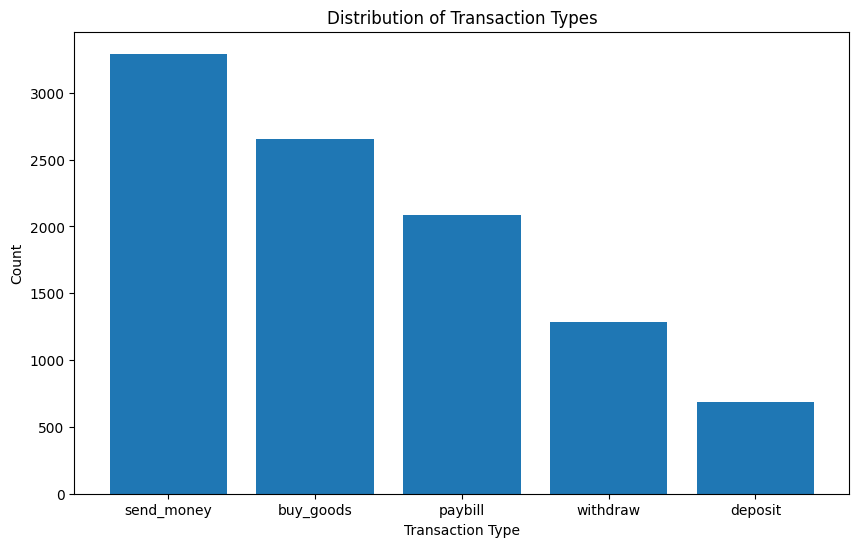

In [45]:
plt.figure(figsize=(10,6))
plt.bar(ttypes_count.index, ttypes_count.values)
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
#plt.xticks(rotation=45)
plt.show()

### Distribution of Transaction Amounts (KES)

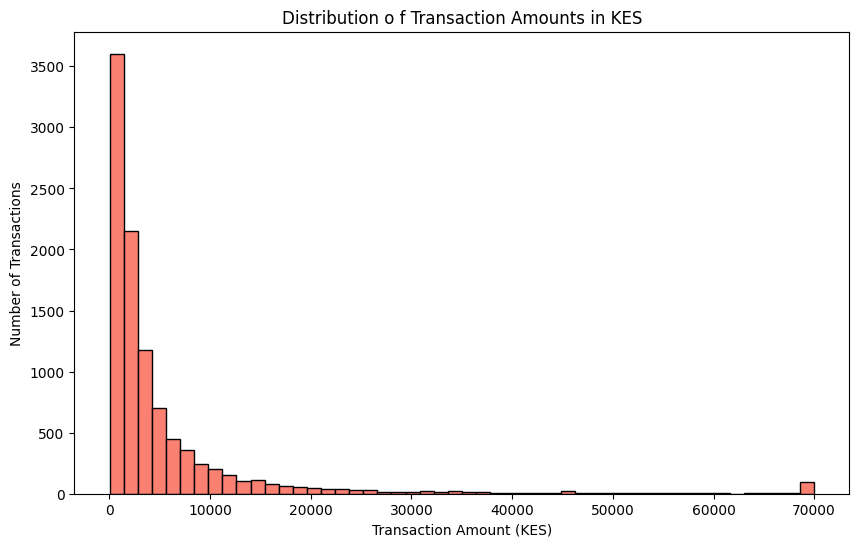

In [46]:
plt.figure(figsize=(10,6))
plt.hist(transactions_df['amount_kes'], bins=50, color='salmon', edgecolor='black')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Number of Transactions')
plt.title('Distribution o f Transaction Amounts in KES')
plt.show()

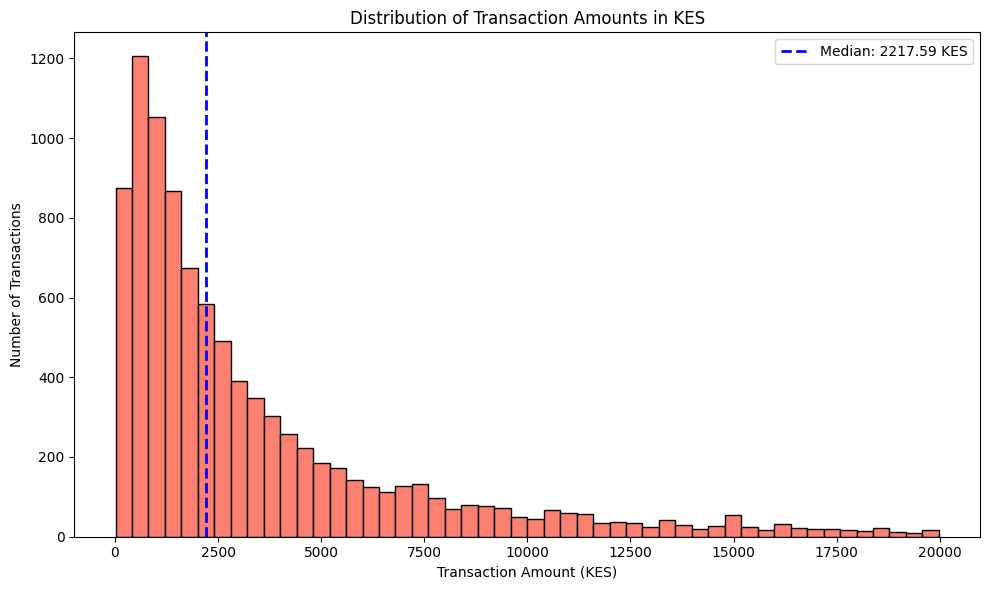

In [47]:
plt.figure(figsize=(10,6))
plt.hist(transactions_df[transactions_df['amount_kes']<20000]['amount_kes'], bins=50, color='salmon', edgecolor='black')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Amounts in KES')
median_amount = transactions_df['amount_kes'].median()
plt.axvline(median_amount, color='blue', linestyle='dashed', linewidth=2, label=f'Median: {median_amount:.2f} KES')
plt.legend()
plt.tight_layout()
plt.show() 

### Pie charts

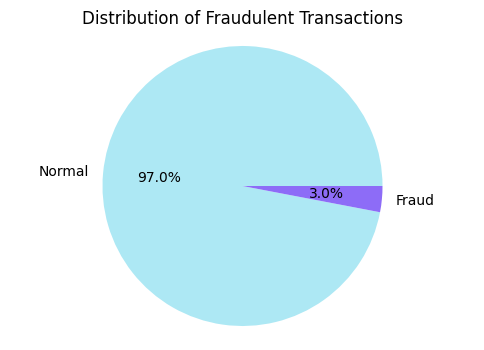

In [48]:
fraud_count = transactions_df['is_fraud'].value_counts()
labels = ['Normal', 'Fraud']
colours = ['#ADE8F4', "#8d6cf7"]
plt.figure(figsize=(6,4))
plt.pie(fraud_count, labels=labels,colors=colours, autopct='%1.1f%%')
plt.title('Distribution of Fraudulent Transactions')
plt.axis('equal')

plt.show()

### Scatter plot

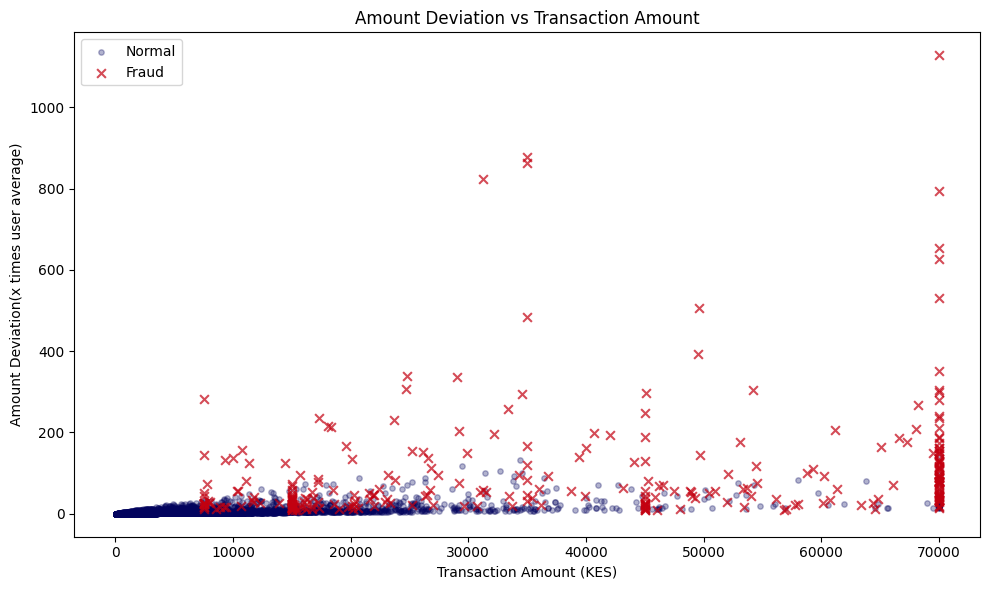

In [49]:
normal = transactions_df[transactions_df['is_fraud'] == 0]
fraud = transactions_df[transactions_df['is_fraud'] == 1]
plt.figure(figsize=(10,6))

plt.scatter(normal['amount_kes'], normal['amount_deviation'], color='#03045E', label='Normal', alpha=0.3,s=15)
plt.scatter(fraud['amount_kes'], fraud['amount_deviation'], color='#C30010', label='Fraud', alpha=0.7,s=40,marker='x')
plt.xlabel('Transaction Amount (KES)')
plt.ylabel('Amount Deviation(x times user average)')
plt.title('Amount Deviation vs Transaction Amount')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
normal['amount_deviation'].describe()

count    9700.000000
mean        2.914026
std         6.994750
min         0.004864
25%         0.376887
50%         0.977913
75%         2.614304
max       139.435983
Name: amount_deviation, dtype: float64

In [51]:
fraud['amount_deviation'].describe()

count     300.000000
mean      101.304099
std       143.327700
min         9.138971
25%        25.154741
50%        52.915712
75%       125.074250
max      1128.044820
Name: amount_deviation, dtype: float64

### Line chart

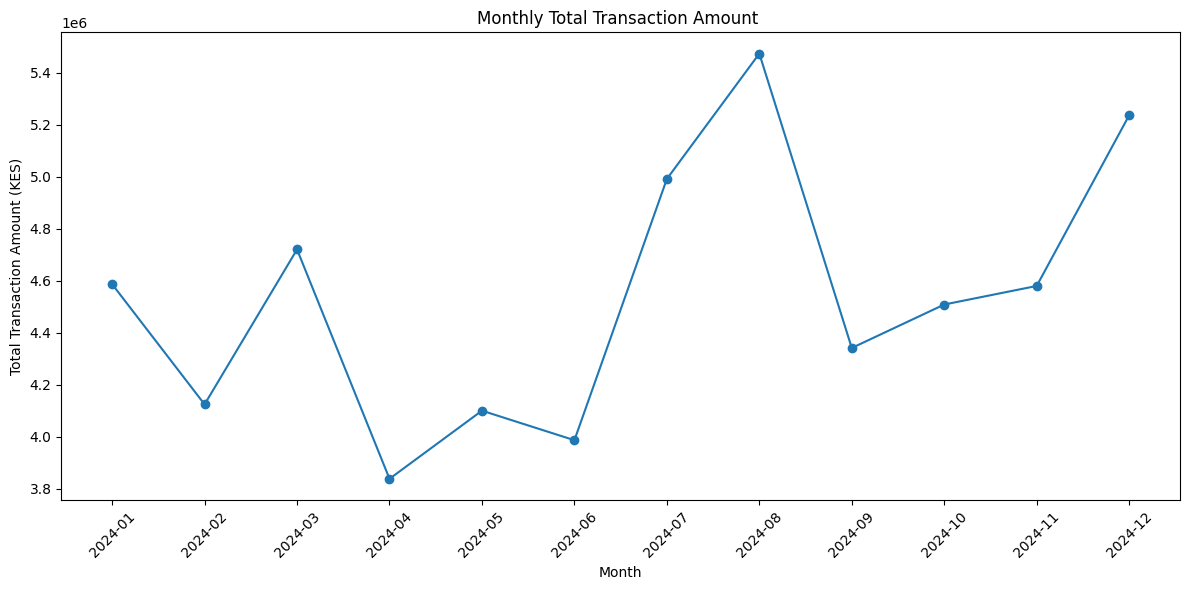

In [52]:
transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
transactions_df['month'] = transactions_df['timestamp'].dt.to_period('M')
monthly_volume = transactions_df.groupby('month')['amount_kes'].sum()
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount (KES)')
plt.title('Monthly Total Transaction Amount ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

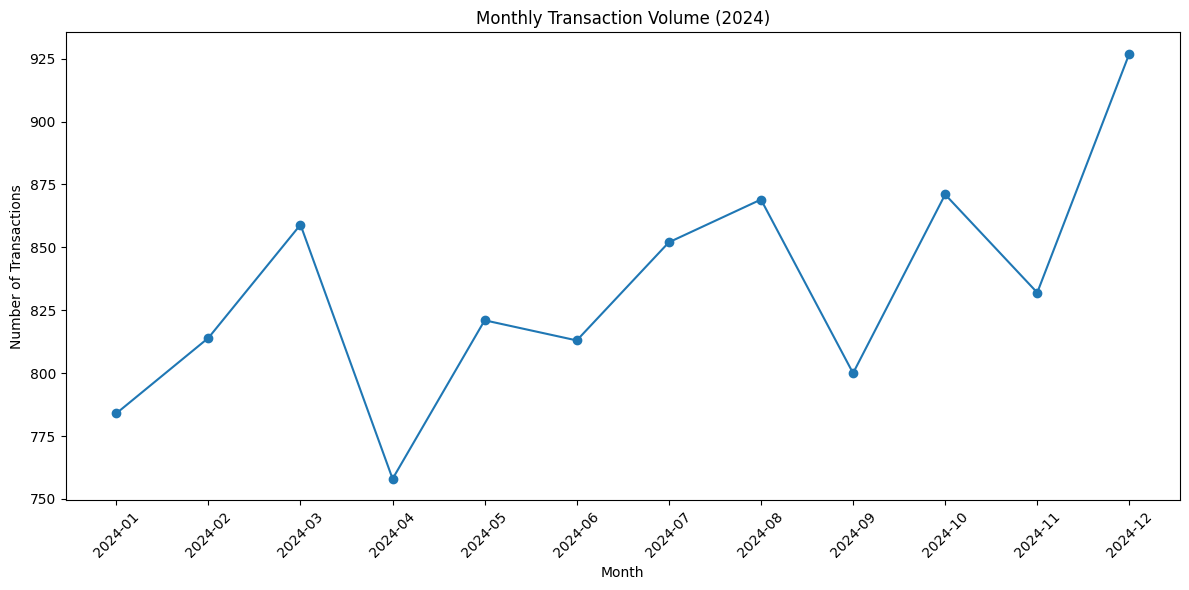

In [53]:
transactions_df['timestamp'] = pd.to_datetime(transactions_df['timestamp'])
transactions_df['month'] = transactions_df['timestamp'].dt.to_period('M')
monthly_volume = transactions_df.groupby('month').size()
plt.figure(figsize=(12,6))
plt.plot(monthly_volume.index.astype(str), monthly_volume.values, marker='o')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.title('Monthly Transaction Volume (2024)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
monthly_volume


month
2024-01    784
2024-02    814
2024-03    859
2024-04    758
2024-05    821
2024-06    813
2024-07    852
2024-08    869
2024-09    800
2024-10    871
2024-11    832
2024-12    927
Freq: M, dtype: int64

In [55]:
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0,2024-09
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0,2024-10


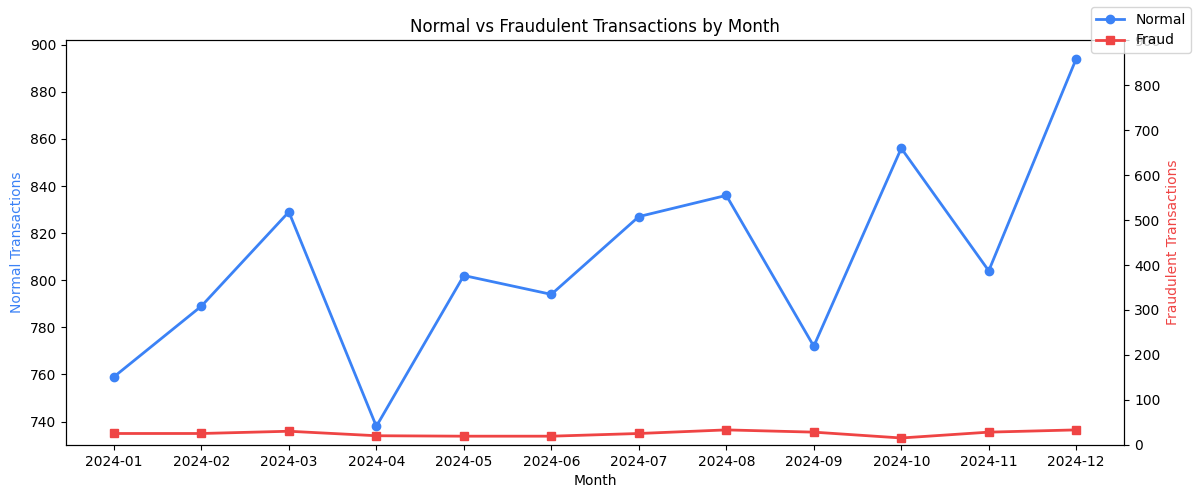

In [70]:
# Count monthly normal transactions
monthly_normal = transactions_df[transactions_df['is_fraud']==0].groupby('month').size()

# Count monthly fraud transactions
monthly_fraud  = transactions_df[transactions_df['is_fraud']==1].groupby('month').size()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left y-axis: normal transaction counts (blue)
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions', color='#3b82f6')

# Right y-axis: fraud counts (red) — different scale
ax2 = ax1.twinx()  # twinx() creates a second y-axis sharing the same x-axis
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions', color='#ef4444')
ax2.set_ylim(0,900)
plt.title('Normal vs Fraudulent Transactions by Month')
ax1.set_xlabel('Month')
plt.xticks(rotation=45)
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()

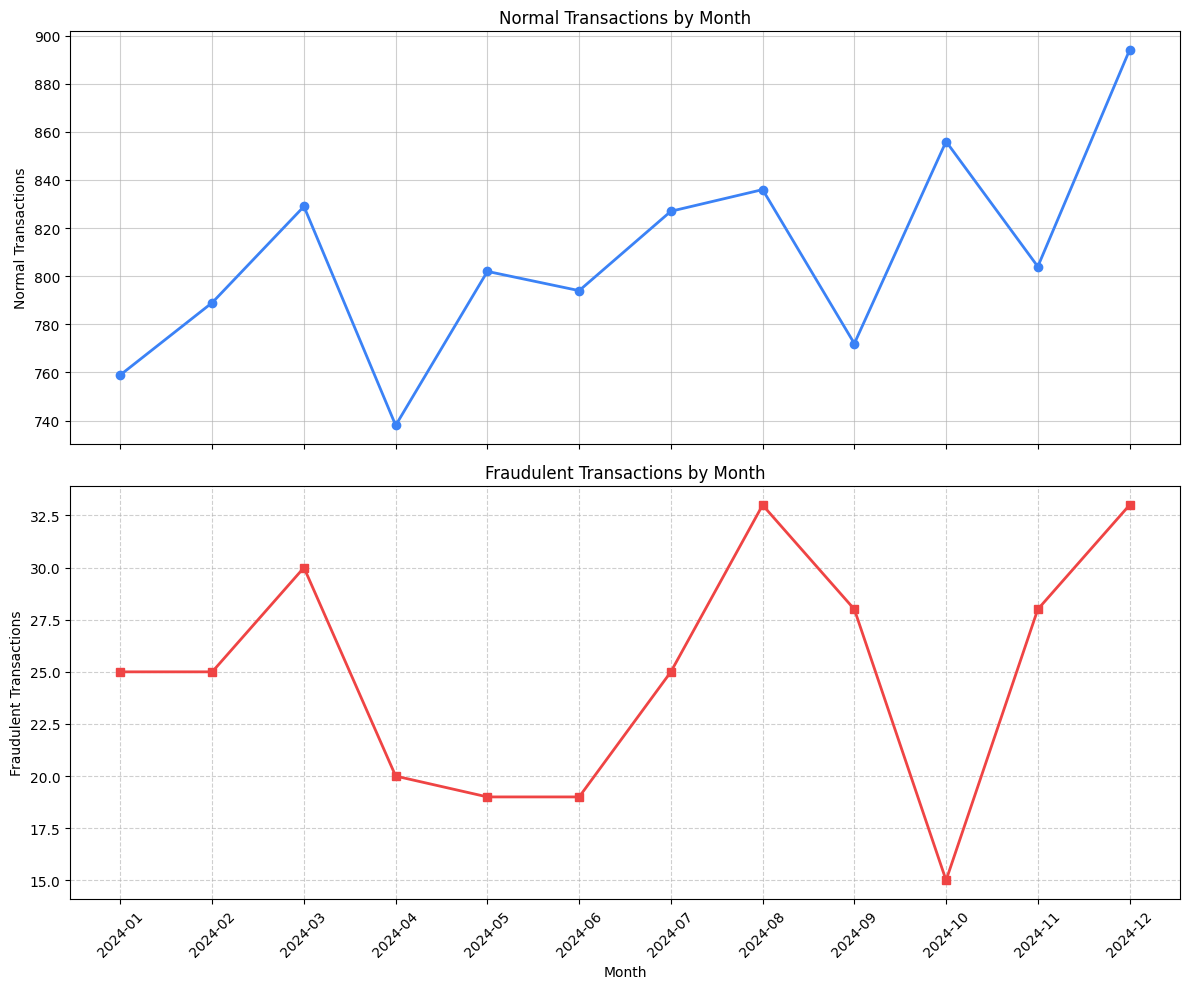

In [57]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)

# Top Plot: Normal Transactions
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions')
ax1.set_title('Normal Transactions by Month')
ax1.grid(True, linestyle='-', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions')
ax2.set_title('Fraudulent Transactions by Month')
ax2.set_xlabel('Month')
ax2.grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [71]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  str           
 1   timestamp         10000 non-null  datetime64[us]
 2   amount_kes        10000 non-null  float64       
 3   hour_of_day       10000 non-null  int64         
 4   is_fraud          10000 non-null  int64         
 5   transaction_type  10000 non-null  str           
 6   day_of_week       10000 non-null  int64         
 7   day_of_month      10000 non-null  int64         
 8   user_id           10000 non-null  str           
 9   user_avg_amount   10000 non-null  float64       
 10  amount_deviation  10000 non-null  float64       
 11  time_diff         8085 non-null   float64       
 12  is_night          10000 non-null  int64         
 13  is_large_tx       10000 non-null  int64         
 14  is_weekend        10000 non-null  

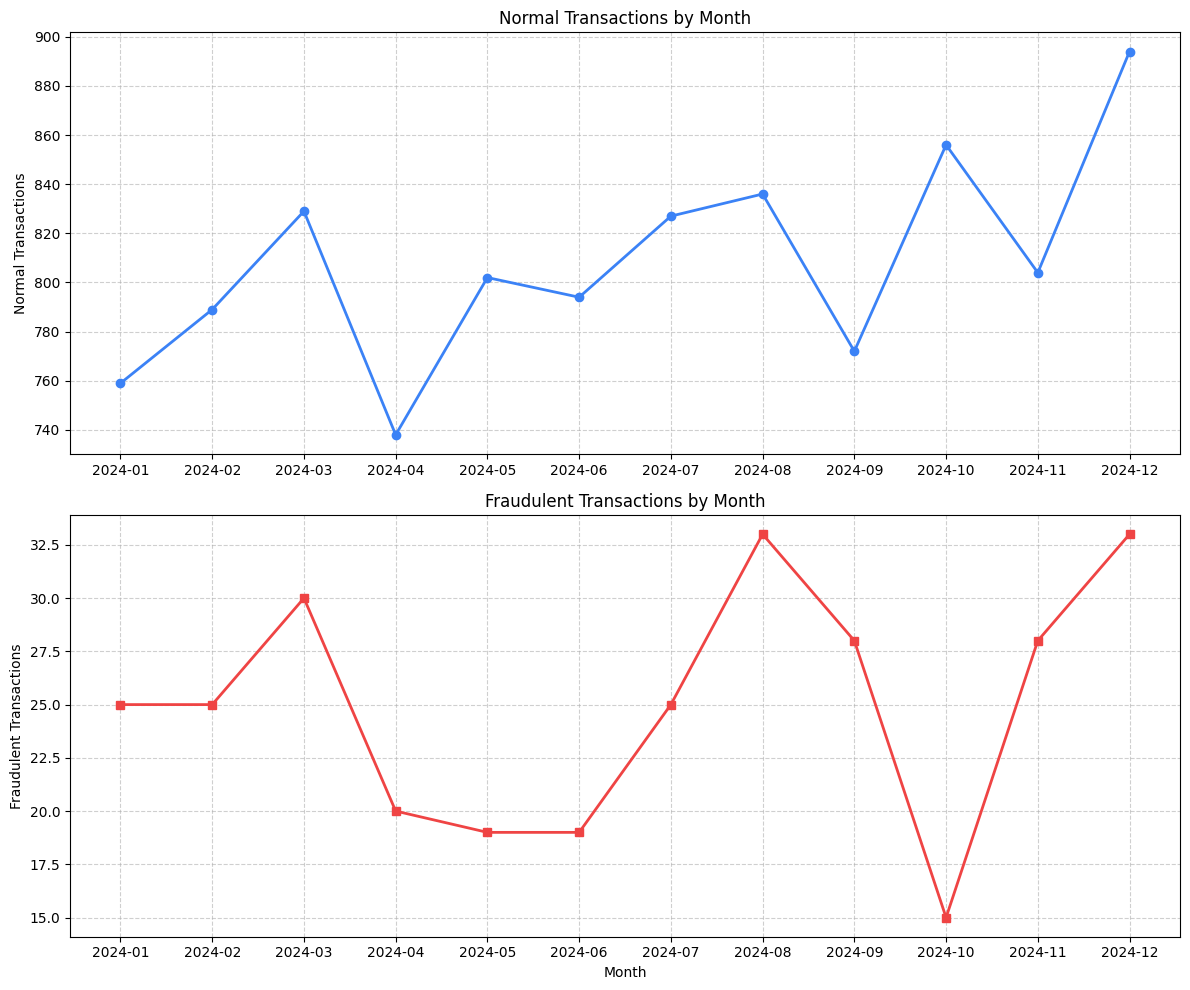

In [58]:
# Create a figure with 2 rows and 1 column
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Top Plot: Normal Transactions
ax1.plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax1.set_ylabel('Normal Transactions')
ax1.set_title('Normal Transactions by Month')
ax1.grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax2.plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax2.set_ylabel('Fraudulent Transactions')
ax2.set_title('Fraudulent Transactions by Month')
ax2.set_xlabel('Month')
ax2.grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.tight_layout()
plt.show()


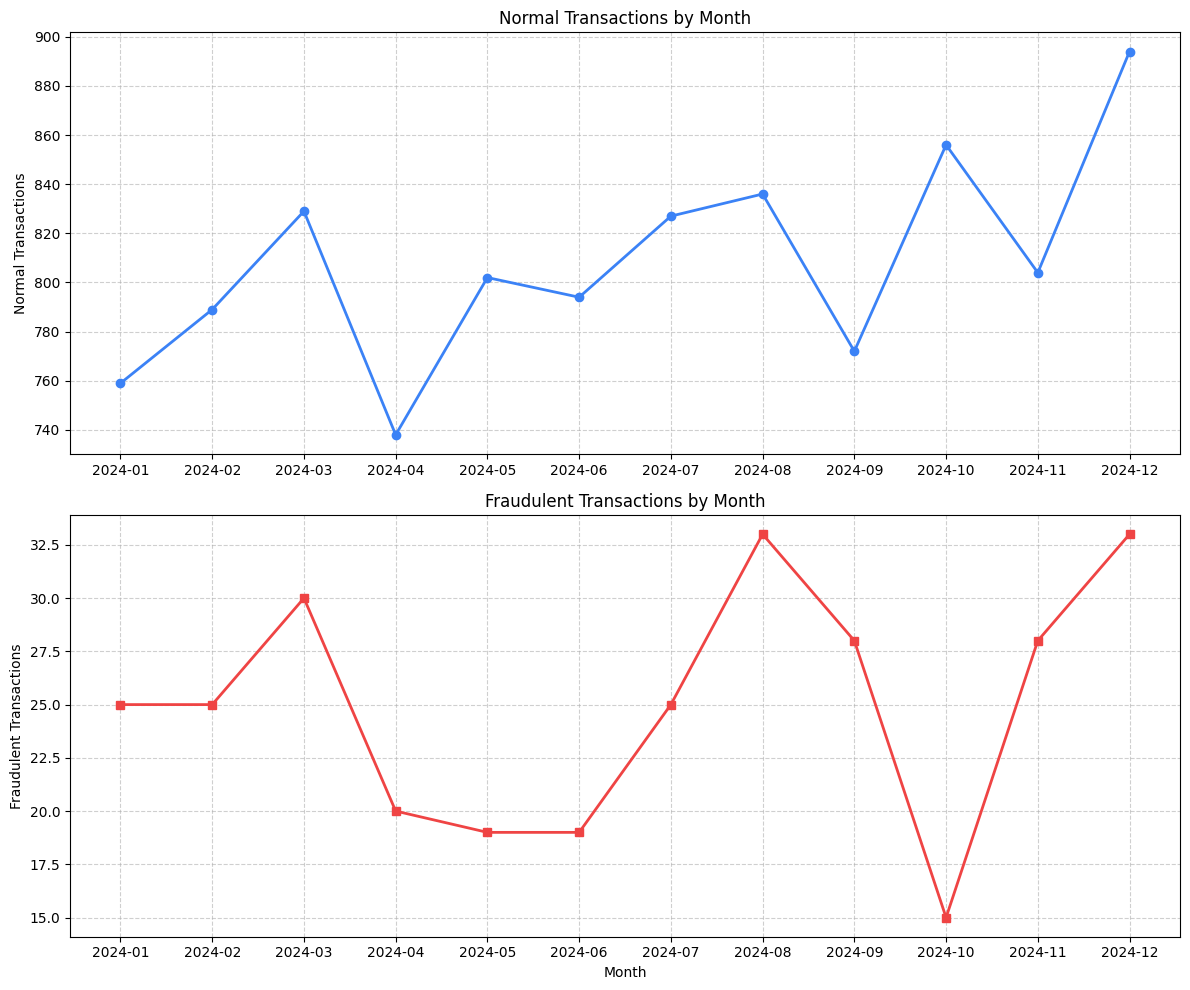

In [59]:
# Create a figure with 2 rows and 1 column
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Top Plot: Normal Transactions
ax[0].plot(monthly_normal.index.astype(str), monthly_normal.values,
        color='#3b82f6', linewidth=2, marker='o', label='Normal')
ax[0].set_ylabel('Normal Transactions')
ax[0].set_title('Normal Transactions by Month')
ax[0].grid(True, linestyle='--', alpha=0.6)

# Bottom Plot: Fraudulent Transactions
ax[1].plot(monthly_fraud.index.astype(str), monthly_fraud.values,
        color='#ef4444', linewidth=2, marker='s', label='Fraud')
ax[1].set_ylabel('Fraudulent Transactions')
ax[1].set_title('Fraudulent Transactions by Month')
ax[1].set_xlabel('Month')
ax[1].grid(True, linestyle='--', alpha=0.6)

# Formatting
plt.tight_layout()
plt.show()


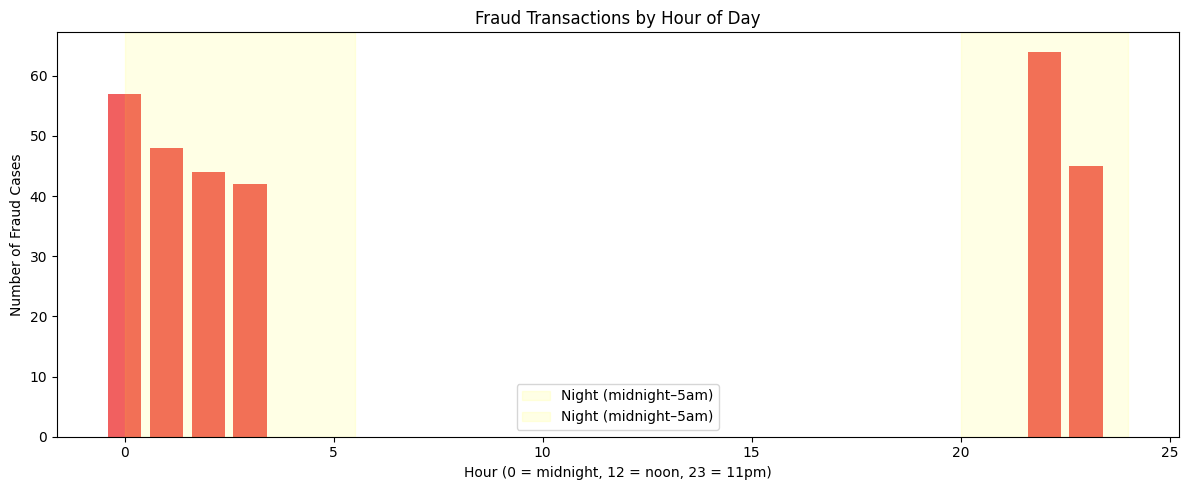

In [72]:
# Group by hour, count fraud cases in each hour
fraud_by_hour = transactions_df[transactions_df['is_fraud']==1].groupby('hour_of_day').size()

plt.figure(figsize=(12, 5))

plt.bar(fraud_by_hour.index, fraud_by_hour.values, color='#ef4444', alpha=0.85)

# Highlight the night hours (0-5am) with a shaded region
plt.axvspan(0, 5.5, alpha=0.1, color='yellow', label='Night (midnight–5am)')
plt.axvspan(20, 24, alpha=0.1, color='yellow', label='Night (midnight–5am)')
plt.title('Fraud Transactions by Hour of Day')
plt.xlabel('Hour (0 = midnight, 12 = noon, 23 = 11pm)')
plt.ylabel('Number of Fraud Cases')

plt.legend()
plt.tight_layout()
plt.show()

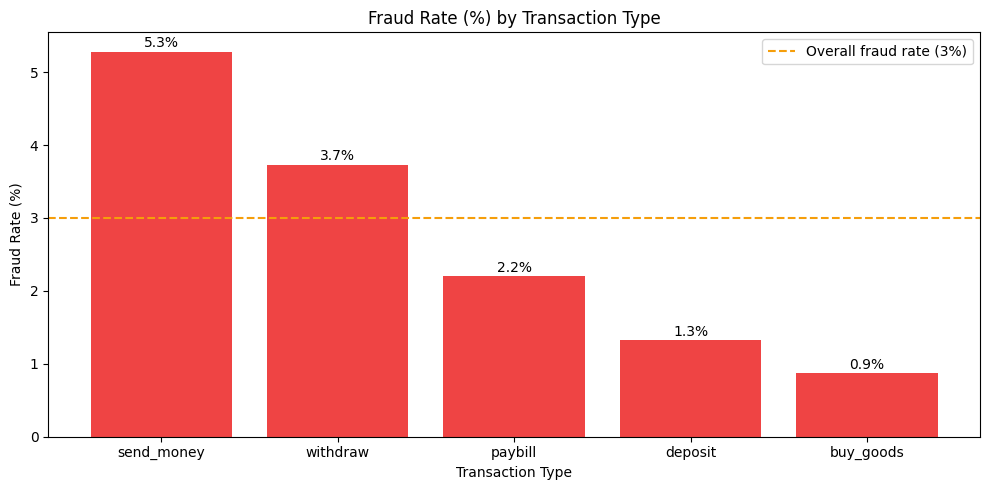

In [61]:
# Calculate the fraud rate for each transaction type
# We want: for each type, what % of transactions are fraud?
fraud_rate = transactions_df.groupby('transaction_type')['is_fraud'].mean() * 100
fraud_rate = fraud_rate.sort_values(ascending=False)

plt.figure(figsize=(10, 5))

bars = plt.bar(fraud_rate.index, fraud_rate.values, color='#ef4444')

# Add a dotted line showing the overall average fraud rate
plt.axhline(y=transactions_df['is_fraud'].mean() * 100,
           color='#f59e0b', linestyle='--', label='Overall fraud rate (3%)')
ax = plt.gca() # Get current axes
ax.bar_label(bars, fmt='%.1f%%', padding=1)
plt.title('Fraud Rate (%) by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

## Seaborn

In [73]:
# Create a readable label column for fraud status
# Instead of 0 and 1, we'll use "Normal" and "Fraud" for chart labels
transactions_df['fraud_label'] = transactions_df['is_fraud'].map({0: 'Normal', 1: 'Fraud'})

# Quick check -- see the first 3 rows
transactions_df.head(3)


,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month,fraud_label
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02,Normal
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07,Normal
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11,Normal


### Countplot

<function matplotlib.pyplot.show(close=None, block=None)>

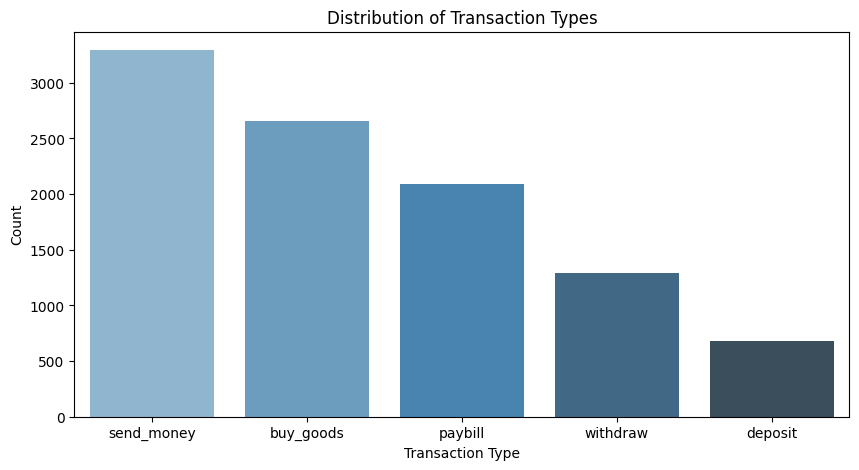

In [75]:
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions_df,x='transaction_type',order=transactions_df['transaction_type'].value_counts().index,palette='Blues_d')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

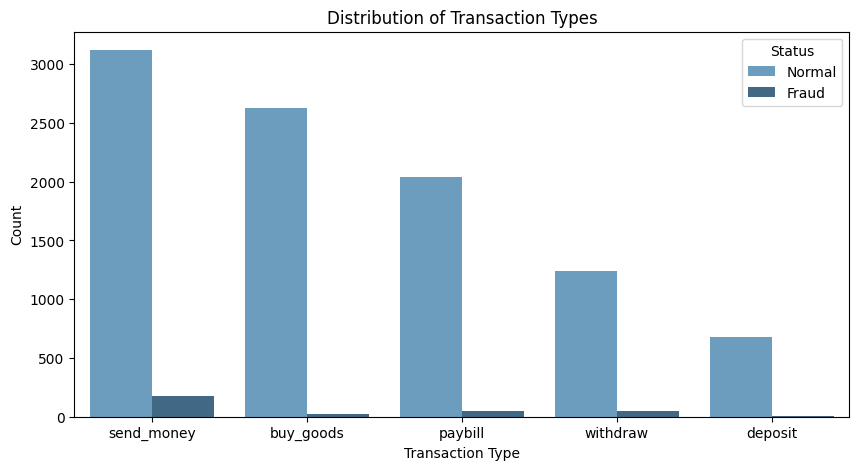

In [63]:
plt.figure(figsize=(10, 5))
sns.countplot(data=transactions_df,x='transaction_type',hue ='is_fraud' ,order=transactions_df['transaction_type'].value_counts().index,palette='Blues_d')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.title('Distribution of Transaction Types')
# Manually setting the legend labels
plt.legend(title='Status', labels=['Normal', 'Fraud'])
plt.show

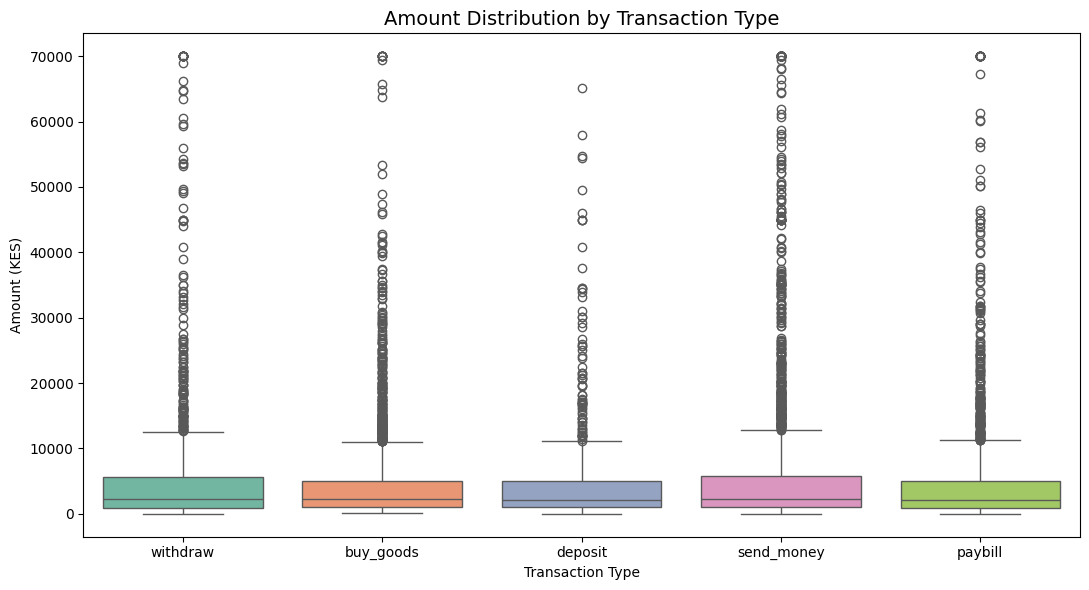

In [64]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df,
    x='transaction_type',
    y='amount_kes',
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

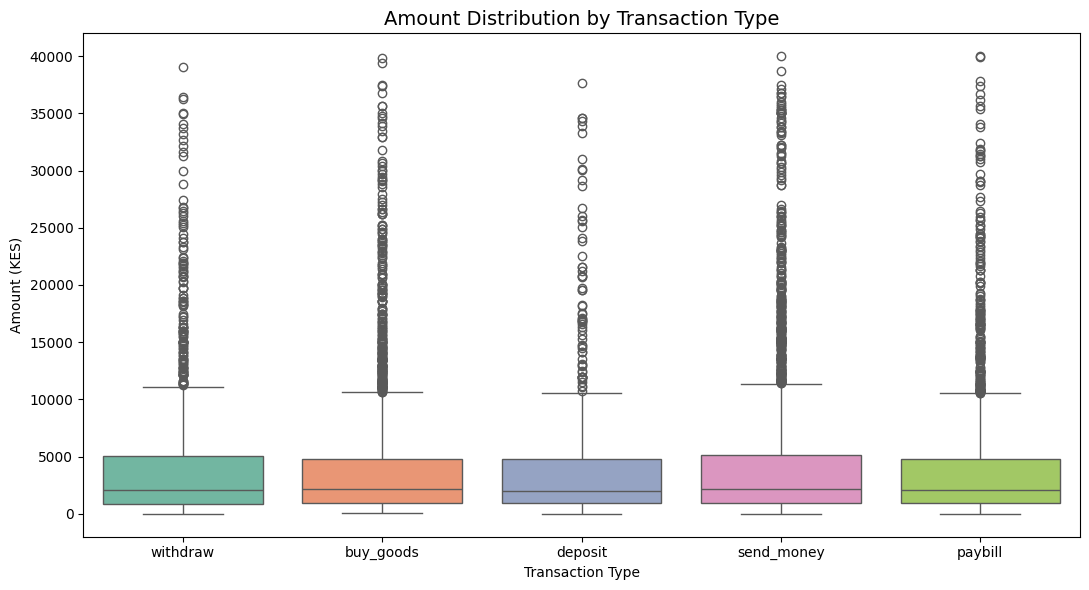

In [65]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df[transactions_df['amount_kes']<40000],  # Filter out extreme outliers for better visualization
    x='transaction_type',
    y='amount_kes',
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

In [66]:
transactions_df['fraud_label'] = transactions_df['is_fraud'].map({0: 'Normal', 1: 'Fraud'})
transactions_df.head()

,transaction_id,timestamp,amount_kes,hour_of_day,is_fraud,transaction_type,day_of_week,day_of_month,user_id,user_avg_amount,amount_deviation,time_diff,is_night,is_large_tx,is_weekend,month,fraud_label
0,TXN0008812,2024-02-24 17:00:00,568.16,17,0,withdraw,5,24,USER01250,3208.326086,0.177089,1137600.0,0,0,1,2024-02,Normal
1,TXN0001970,2024-07-10 07:00:00,1264.23,7,0,withdraw,2,10,USER00922,309.857126,4.080042,309600.0,0,0,0,2024-07,Normal
2,TXN0009625,2024-11-18 11:00:00,735.39,11,0,buy_goods,0,18,USER00342,4456.268596,0.165024,3362400.0,0,0,0,2024-11,Normal
3,TXN0003226,2024-09-09 11:00:00,8769.07,11,0,deposit,0,9,USER00935,2283.433868,3.840300,2239200.0,0,0,0,2024-09,Normal
4,TXN0008942,2024-10-03 17:00:00,20811.30,17,0,withdraw,3,3,USER00888,4519.251559,4.605032,2700000.0,0,1,0,2024-10,Normal


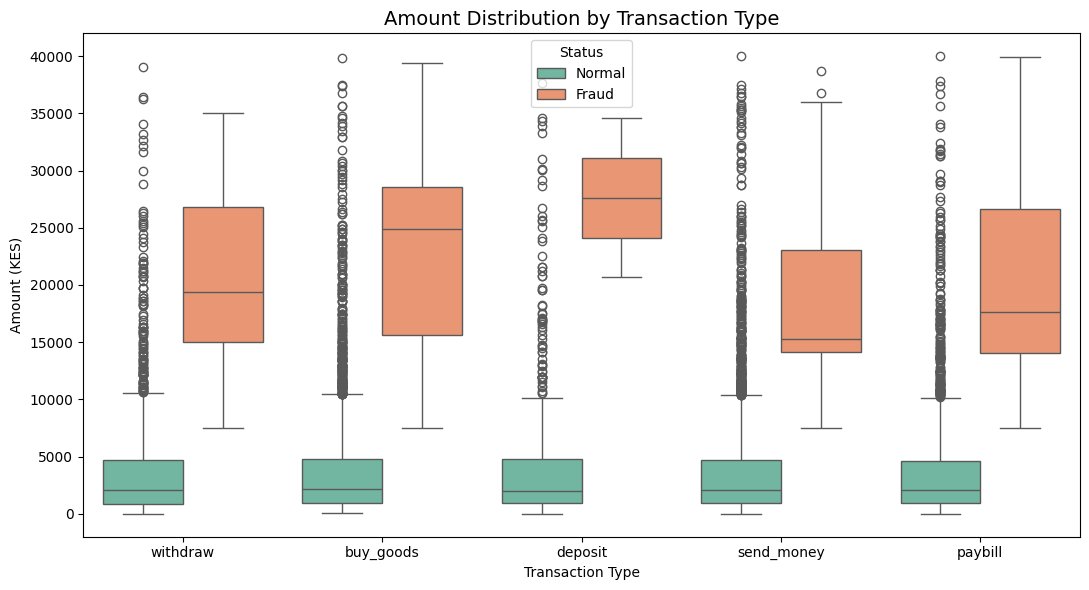

In [67]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=transactions_df[transactions_df['amount_kes']<40000],  # Filter out extreme outliers for better visualization
    x='transaction_type',
    y='amount_kes',
    hue='fraud_label',  # Add hue to differentiate between normal and fraud transactions   
    palette='Set2'   # 'Set2' is a Seaborn palette with distinct muted colours
)

plt.title('Amount Distribution by Transaction Type', fontsize=14)
plt.xlabel('Transaction Type')
plt.ylabel('Amount (KES)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()